<h2>Визуализация временных рядов (темпоральных данных) на R </h2>

<h2>Часть 1</h2>
<h3>Построение столбчатой диаграммы</h3>

<h4>1.1 Загрузка данных</h4>


In [1]:
hotdogs <- read.csv("http://datasets.flowingdata.com/hot-dog-contest-winners.csv", sep = ",", header = TRUE)

In [2]:
hotdogs

Year,Winner,Dogs.eaten,Country,New.record
<int>,<chr>,<dbl>,<chr>,<int>
1980,Paul Siederman & Joe Baldini,9.10,United States,0
1981,Thomas DeBerry,11.00,United States,0
1982,Steven Abrams,11.00,United States,0
1983,Luis Llamas,19.50,Mexico,0
1984,Birgit Felden,9.50,Germany,0
1985,Oscar Rodriguez,11.75,United States,0
1986,Mark Heller,15.50,United States,0
1987,Don Wolfman,12.00,United States,0
1988,Jay Green,14.00,United States,0


<h4>1.2. Строим столбцовую диаграмму</h4>

In [6]:
# Выделяем рекордные года цветом
fill_colors <- c()
for (i in 1:length(hotdogs$New.record)) {
    if (hotdogs$New.record[i] == 1) {
        fill_colors <- c(fill_colors, "#821122")
    } else {
        fill_colors <- c(fill_colors, "#cccccc")
    }
}

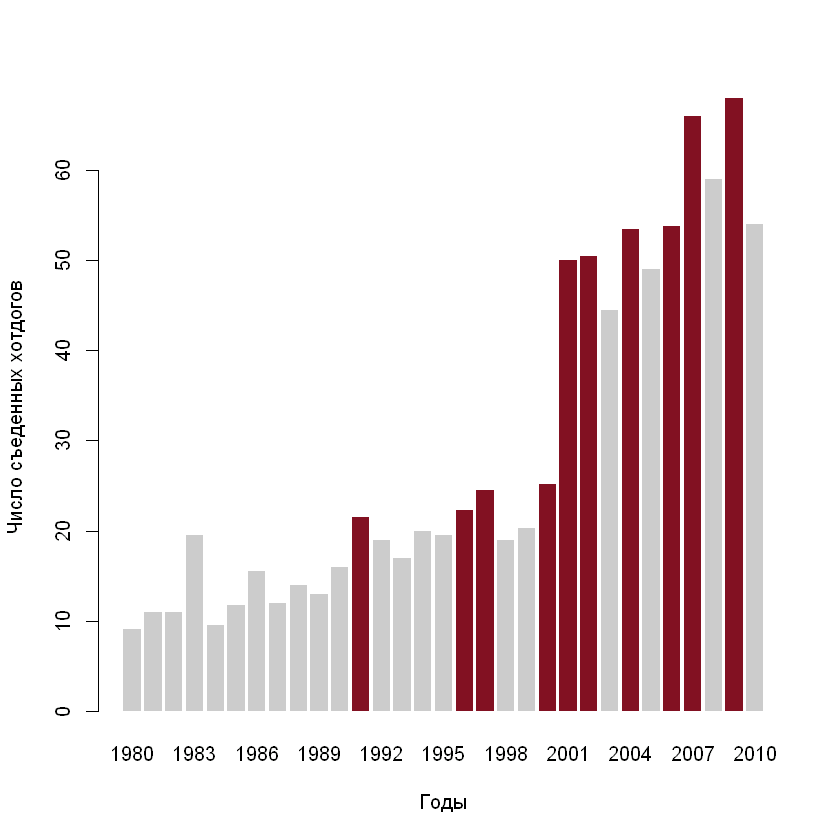

In [8]:
barplot(hotdogs$Dogs.eaten, names.arg = hotdogs$Year, col = fill_colors, border = NA, xlab = "Годы", ylab = "Число съеденных хотдогов")

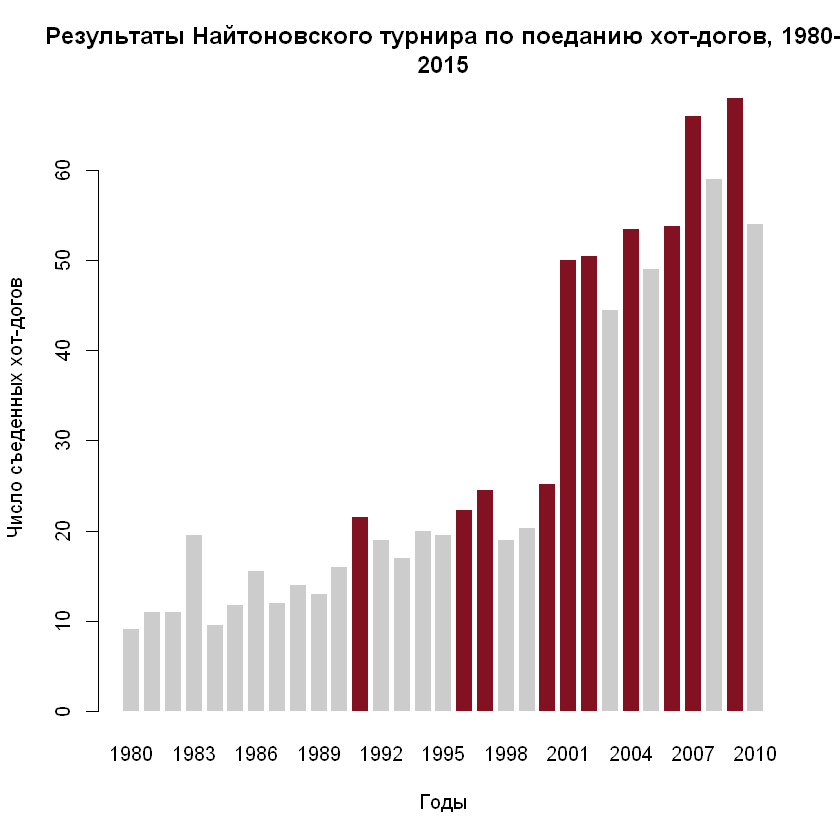

In [9]:
barplot(hotdogs$Dogs.eaten, names.arg=hotdogs$Year, col=fill_colors, border=NA, space=0.3, xlab="Годы",
ylab="Число съеденных хот-догов", main="Результаты Найтоновского турнира по поеданию хот-догов, 1980-
2015")

<h4>1.3. Сохранение графика в pdf-файл</h4>
NimbusSan у меня не сработал, воспользовался дополнительной библиотекой

In [13]:
install.packages("Cairo")

Устанавливаю пакет в 'C:/Users/ol1xy/AppData/Local/R/win-library/4.5'
(потому что 'lib' не определено)



пакет 'Cairo' успешно распакован, MD5-суммы проверены

Скачанные бинарные пакеты находятся в
	C:\Users\ol1xy\AppData\Local\Temp\RtmpCE6CSs\downloaded_packages


In [14]:
library(Cairo)

CairoPDF("Nathan.pdf", family = "Arial") # Или другой системный шрифт с кириллицей
barplot(hotdogs$Dogs.eaten, names.arg=hotdogs$Year, col=fill_colors, 
        border=NA, space=0.5, xlab="Годы",
        ylab="Число съеденных хот-догов", 
        main="Результаты Найтоновского турнира по поеданию хот-догов")
dev.off()

pdf 
  2

<h3>2. Построение штабельной диаграммы</h3>
<h4>2.1 Загрузка данных</h4>

In [15]:
hot_dog_places <- read.csv('http://datasets.flowingdata.com/hot-dog-places.csv', sep=",", header=TRUE)

In [16]:
hot_dog_places

X2000,X2001,X2002,X2003,X2004,X2005,X2006,X2007,X2008,X2009,X2010
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<int>
25,50.0,50.5,44.5,53.5,49,54,66,59,68.0,54
24,31.0,26.0,30.5,38.0,37,52,63,59,64.5,43
22,23.5,25.5,29.5,32.0,32,37,49,42,55.0,37


<h4>2.2. Ручная смена формата</h4>

In [18]:
names(hot_dog_places) <- c("2000", "2001", "2002", "2003", "2004", "2005", "2006", "2007", "2008", "2009",
"2010")

In [19]:
hot_dog_places

2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<int>
25,50.0,50.5,44.5,53.5,49,54,66,59,68.0,54
24,31.0,26.0,30.5,38.0,37,52,63,59,64.5,43
22,23.5,25.5,29.5,32.0,32,37,49,42,55.0,37


<h4>2.3. Построение диаграммы</h4>

In [21]:
hot_dog_matrix <- as.matrix((hot_dog_places))

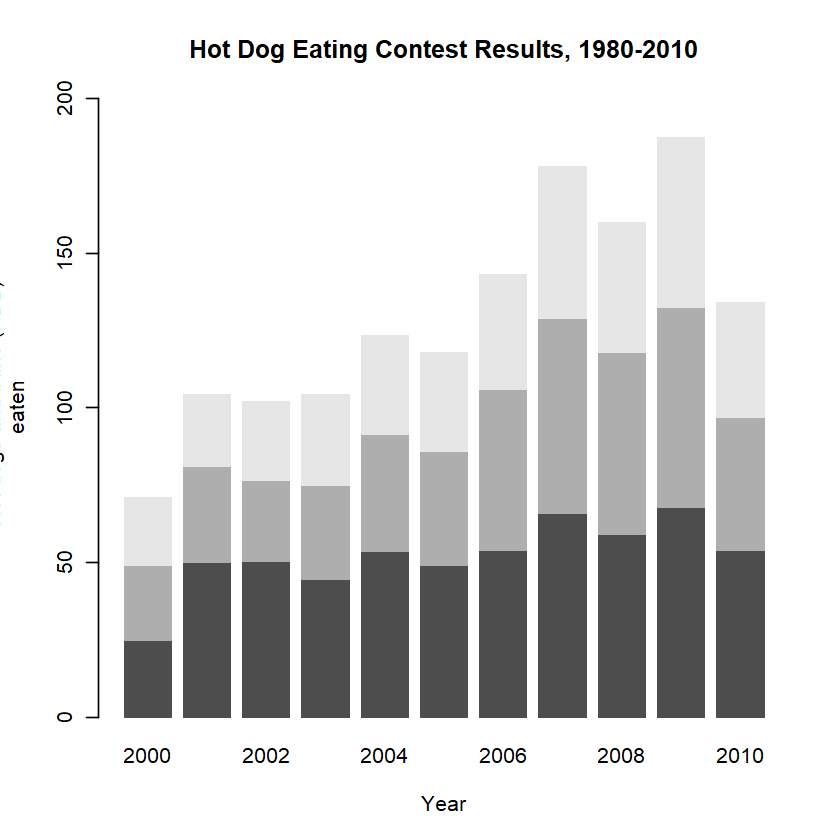

In [22]:
barplot(hot_dog_matrix, border=NA, space=0.25, ylim=c(0, 200), xlab="Year", ylab="Hot dogs and buns (HDB)
eaten", main="Hot Dog Eating Contest Results, 1980-2010")

<h3>3. Построение диаграммы рассеяния</h3>
Используем данные подсчета подписчиков FlowingData

In [23]:
subscribers <-read.csv("http://datasets.flowingdata.com/flowingdata_subscribers.csv", sep=",", header=TRUE)

In [ ]:
subscribers[1:5, ]

,Date,Subscribers,Reach,Item.Views,Hits
,<chr>,<int>,<int>,<int>,<int>
1,01-01-2010,25047,4627,9682,27225
2,01-02-2010,25204,1676,5434,28042
3,01-03-2010,25491,1485,6318,29824
4,01-04-2010,26503,6290,17238,48911
5,01-05-2010,26654,6544,16224,45521


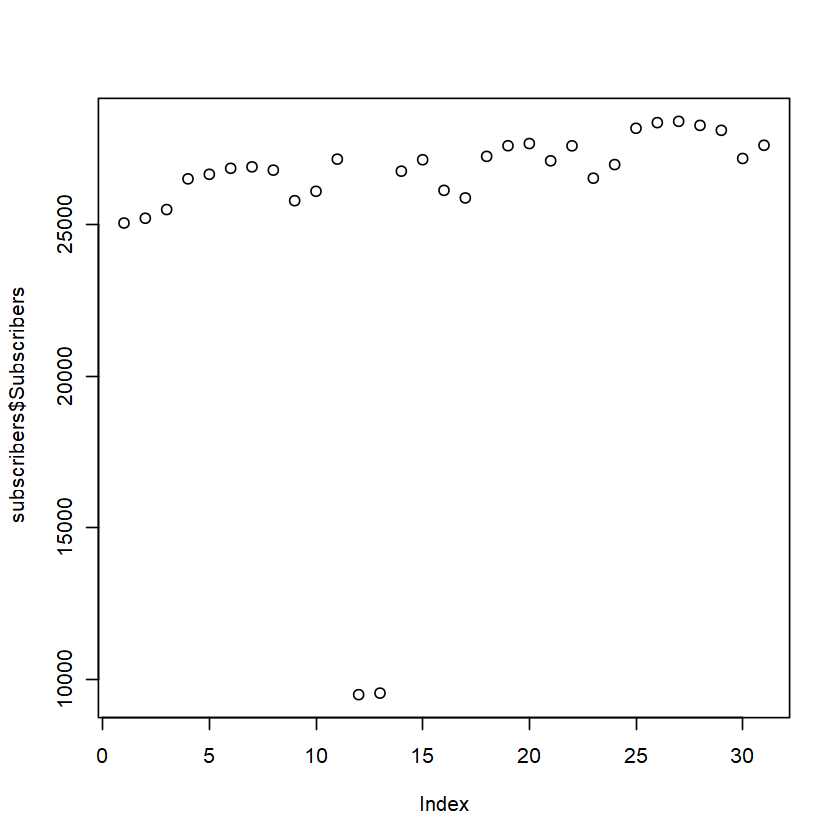

In [26]:
plot(subscribers$Subscribers)

<h4>3.1. Точечная диаграмма в R с заданными предельными значениями оси Y</h4>

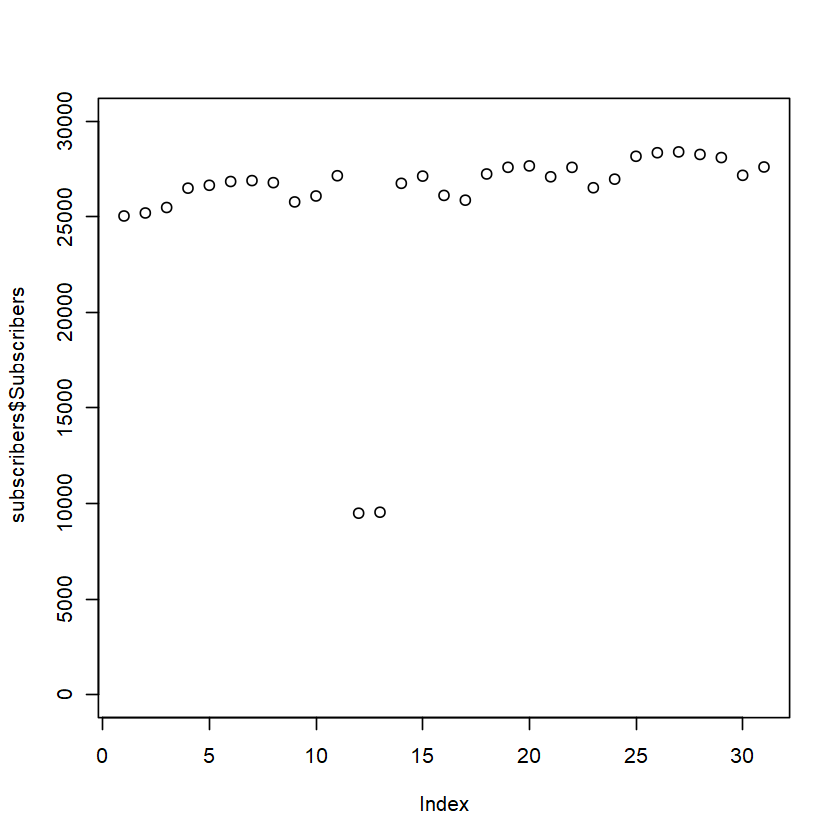

In [27]:
plot(subscribers$Subscribers, type="p", ylim=c(0, 30000))

<h4>3.2. Линейчатая диаграмма</h4>

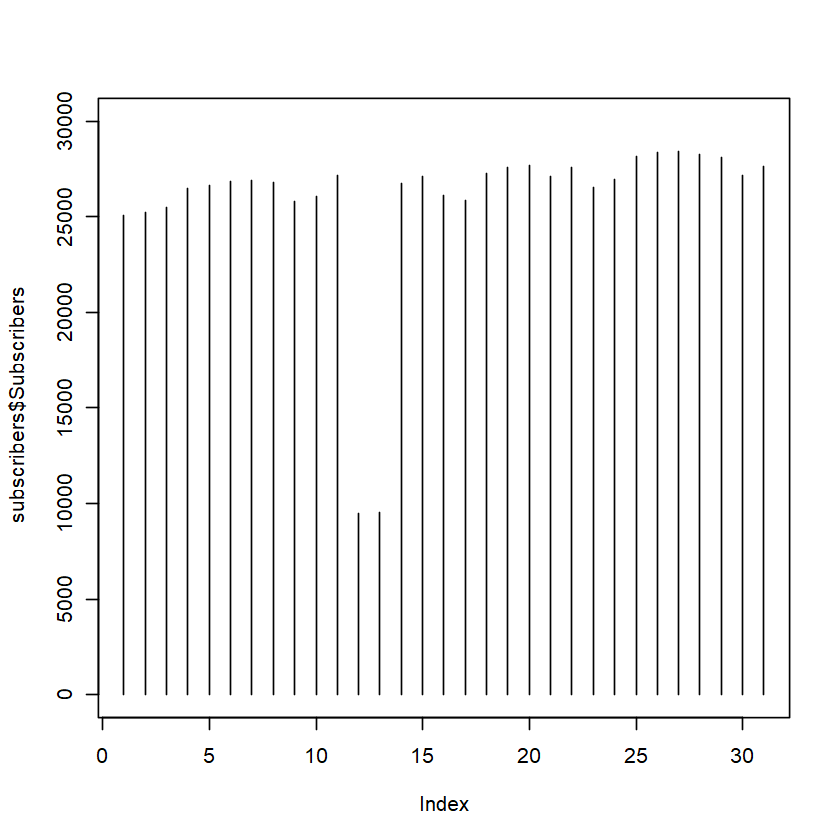

In [28]:
plot(subscribers$Subscribers, type="h", ylim=c(0, 30000))

<h4>3.3. Комбинированная диаграмма из точек и линий</h4>

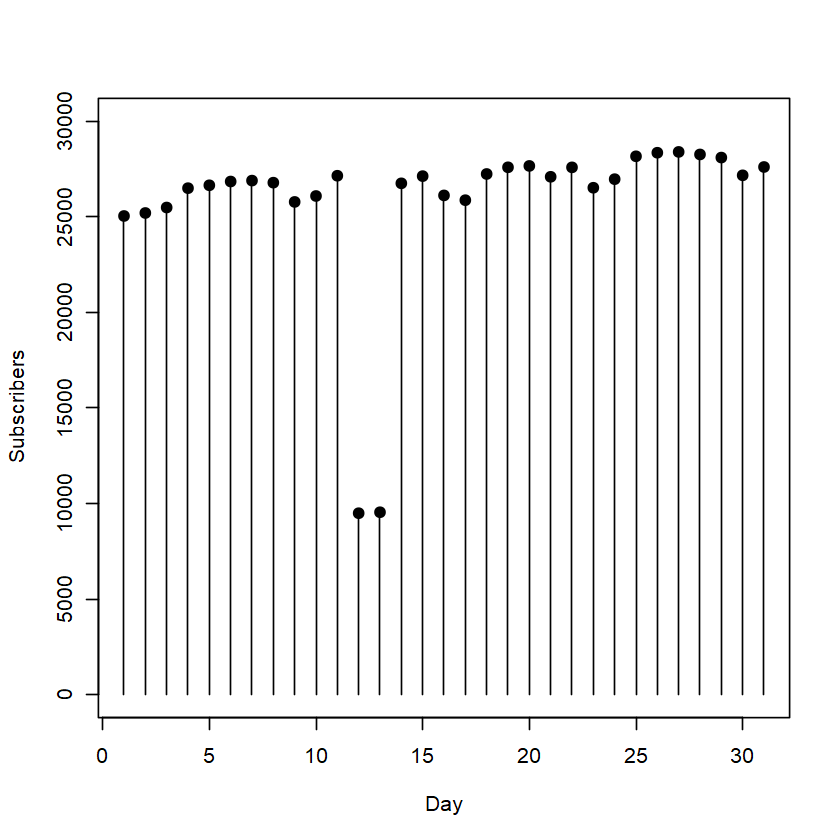

In [29]:
plot(subscribers$Subscribers, type="h", ylim=c(0, 30000), xlab="Day", ylab="Subscribers")
points(subscribers$Subscribers, pch=19, col="black")

<h3>4. Построение графика</h3>

<h4>4.1. Загрузка данных </h4>

In [30]:
population <-read.csv("http://datasets.flowingdata.com/world-population.csv", sep=",", header=TRUE)

In [31]:
population[1:5, ] 

,Year,Population
,<int>,<dbl>
1,1960,3028654024
2,1961,3068356747
3,1962,3121963107
4,1963,3187471383
5,1964,3253112403


<h4>4.2. Построение графика</h4>

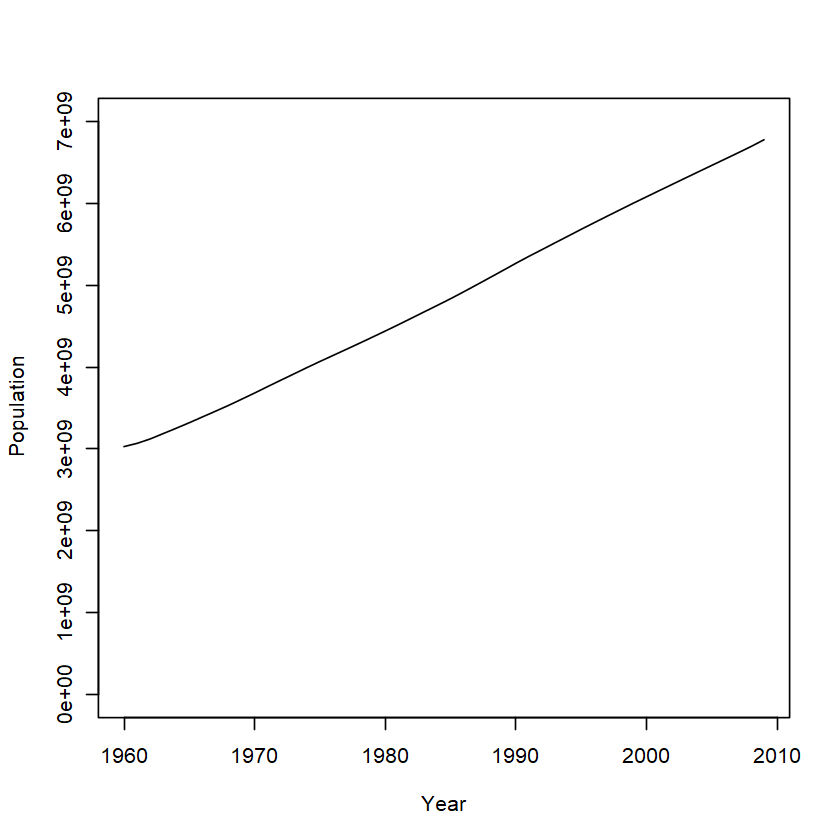

In [32]:
plot(population$Year, population$Population, type="l", ylim=c(0, 7000000000), xlab="Year", ylab="Population")

<h3>5. Ступенчатая диаграмма</h3>

<h4>5.1. Загрузка данных</h4>

In [33]:
postage <- read.csv("http://datasets.flowingdata.com/us-postage.csv", sep=",", header=TRUE)

In [34]:
postage

Year,Price
<int>,<dbl>
1991,0.29
1995,0.32
1999,0.33
2001,0.34
2002,0.37
2006,0.39
2007,0.41
2008,0.42
2009,0.44


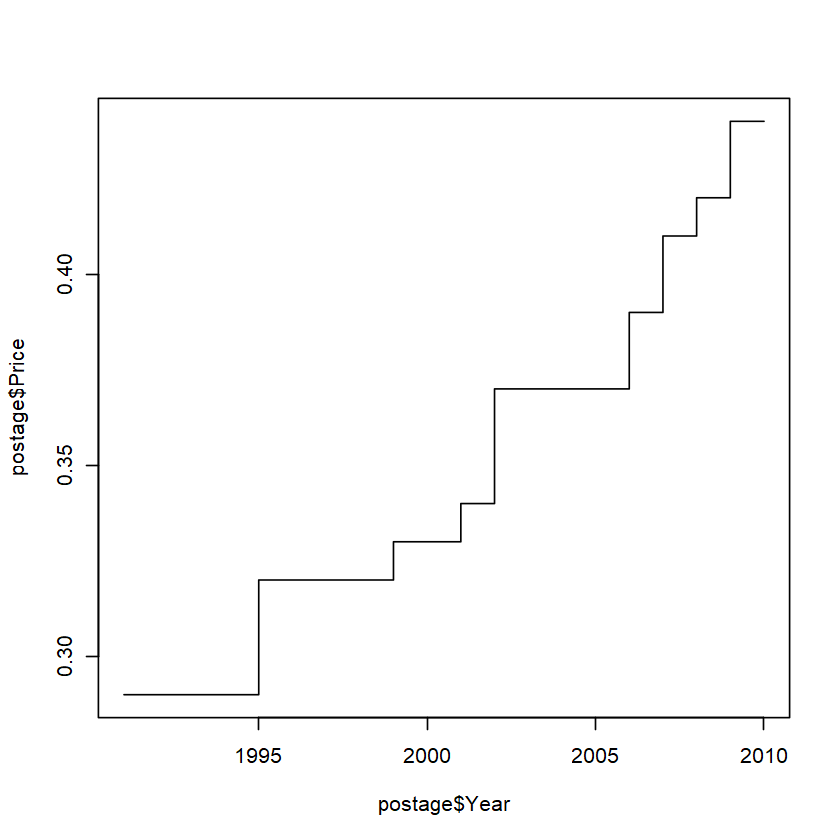

In [35]:
plot(postage$Year, postage$Price, type="s")

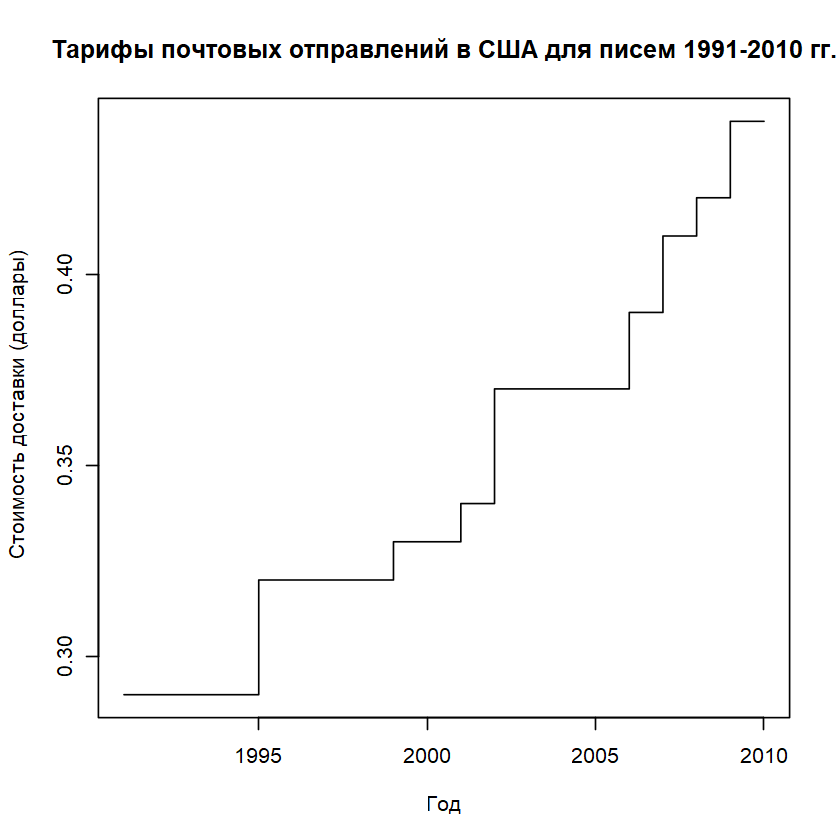

In [36]:
plot(postage$Year, postage$Price, type="s", main="Тарифы почтовых отправлений в США для писем 1991-2010 гг.", xlab="Год", ylab="Стоимость доставки (доллары)")

<h3>6. Сглаживание и оценка</h3>

In [37]:
unemployment <- read.csv("http://datasets.flowingdata.com/unemployment-rate-1948-2010.csv", sep=",", header=TRUE)

In [38]:
unemployment[1:10, ]

,Series.id,Year,Period,Value
,<chr>,<int>,<chr>,<dbl>
1,LNS14000000,1948,M01,3.4
2,LNS14000000,1948,M02,3.8
3,LNS14000000,1948,M03,4.0
4,LNS14000000,1948,M04,3.9
5,LNS14000000,1948,M05,3.5
6,LNS14000000,1948,M06,3.6
7,LNS14000000,1948,M07,3.6
8,LNS14000000,1948,M08,3.9
9,LNS14000000,1948,M09,3.8


<h4>6.1. Кривая тренда</h4>

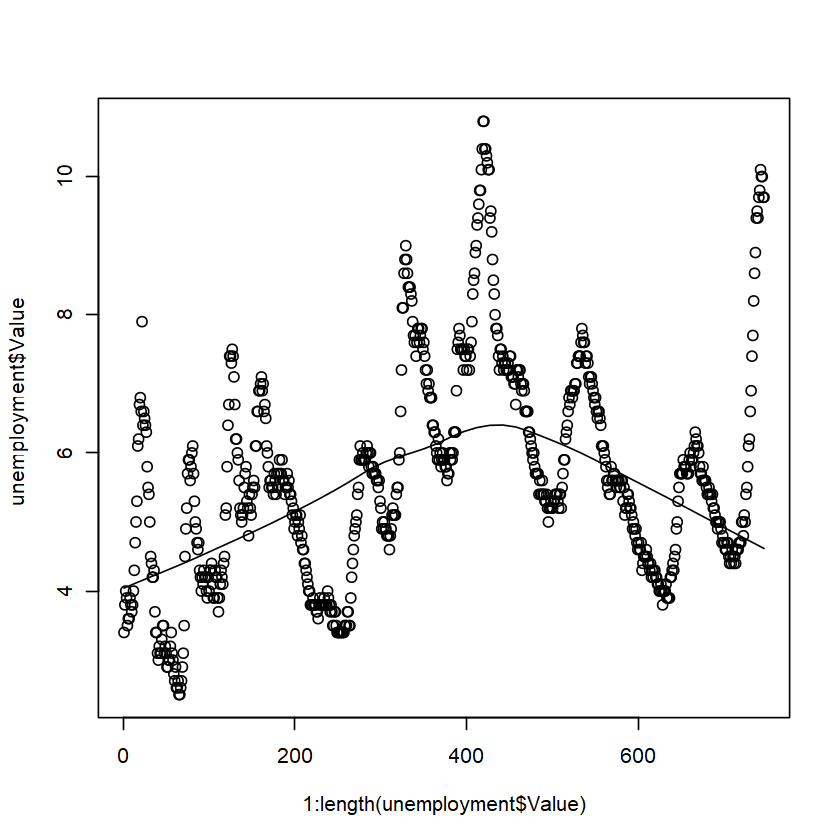

In [39]:
scatter.smooth(x=1:length(unemployment$Value), y=unemployment$Value)

То, насколько сглаженной должна получиться кривая, можно задать через аргументы degree
(степень) и span (интервал) в функции scatter.smooth(). Первый из них контролирует степень полиномов, а
второй — то, насколько гладкой получится кривая. Чем ближе интервал к нулю, тем точнее будет подгонка.

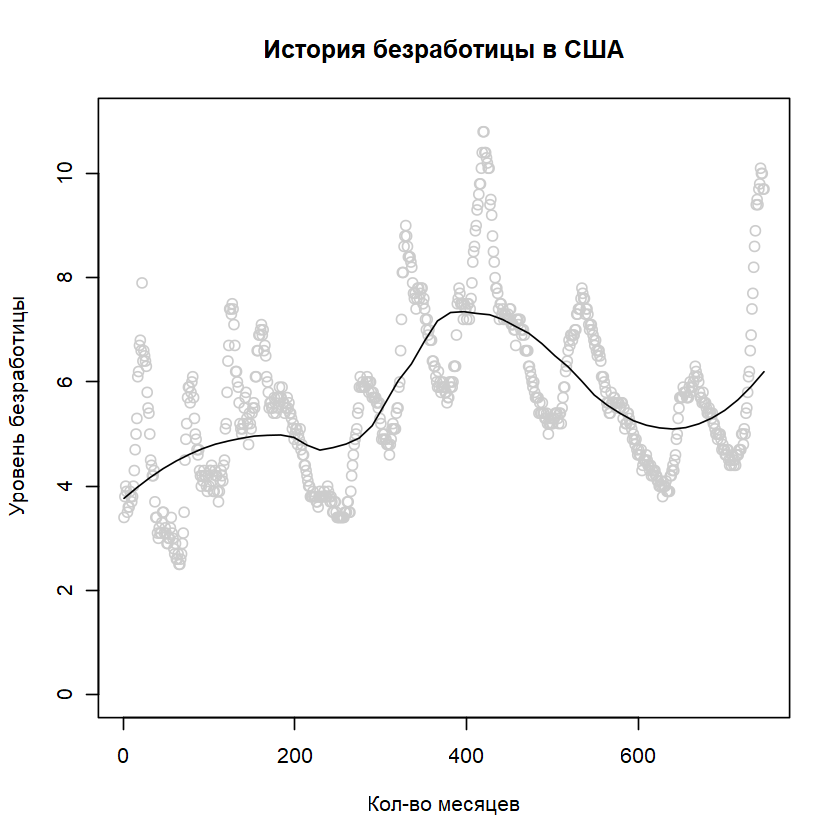

In [40]:
scatter.smooth(x=1:length(unemployment$Value), y=unemployment$Value, ylim=c(0,11), degree=2, col="#CCCCCC", span=0.5, main="История безработицы в США", xlab="Кол-во месяцев", ylab="Уровень безработицы")

<h2>Часть 2</h2>

<h3>1. Уровень преступности в США по штатам</h3>

In [41]:
crime <-read.csv("http://datasets.flowingdata.com/crimeRatesByState2005.csv", sep=",", header=TRUE)

In [44]:
crime[1:5, ]

,state,murder,forcible_rape,robbery,aggravated_assault,burglary,larceny_theft,motor_vehicle_theft,population
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,United States,5.6,31.7,140.7,291.1,726.7,2286.3,416.7,295753151
2,Alabama,8.2,34.3,141.4,247.8,953.8,2650.0,288.3,4545049
3,Alaska,4.8,81.1,80.9,465.1,622.5,2599.1,391.0,669488
4,Arizona,7.5,33.8,144.4,327.4,948.4,2965.2,924.4,5974834
5,Arkansas,6.7,42.9,91.1,386.8,1084.6,2711.2,262.1,2776221


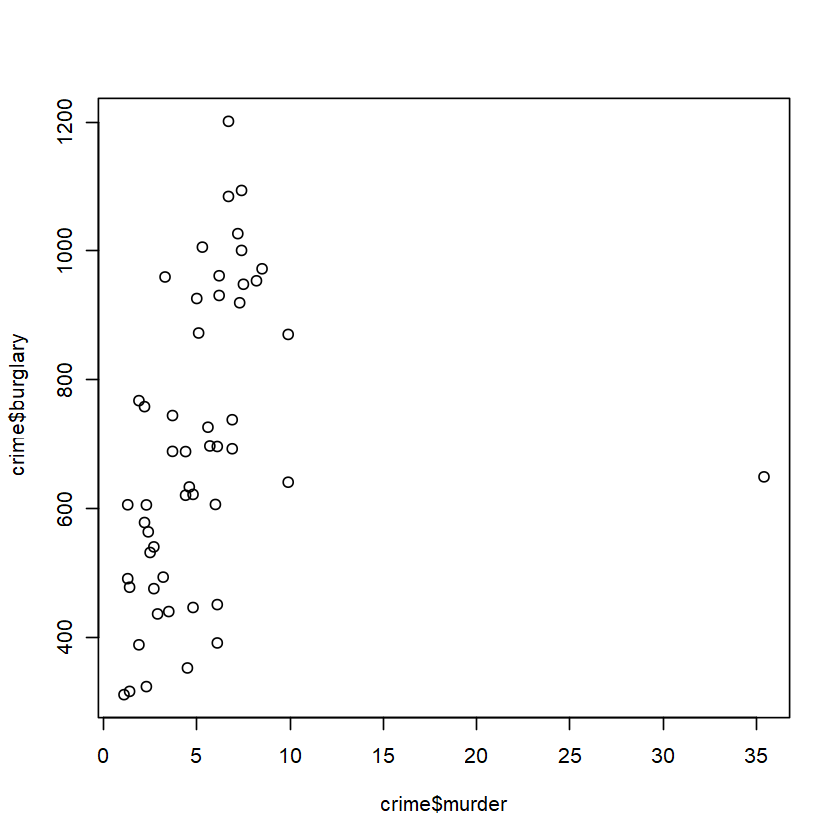

In [45]:
plot(crime$murder, crime$burglary)

- Линейная зависимость (точки выстраиваются примерно вдоль прямой линии, идущей из левого нижнего угла в правый верхний). Положительная корреляция
- Эта одинокая точка в правом углу — или выброс — вынуждает горизонтальную ось сильно вытягиваться в ширину. Точка представляет Вашингтон, округ Колумбия
- Удалим выброс и средние данныые по США, чтобы диаграмма получилась более наглядной и полезно


In [46]:
crime2 <- crime[crime$state != "District of Columbia", ]
crime2 <- crime2[crime2$state != "United States", ]

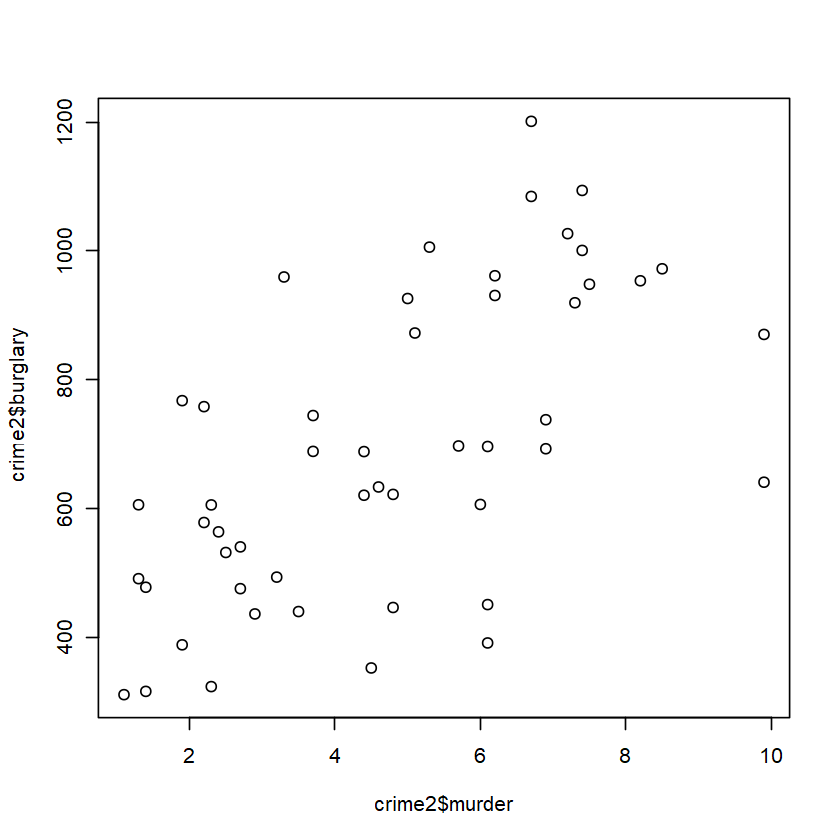

In [47]:
plot (crime2$murder, crime2$burglary)

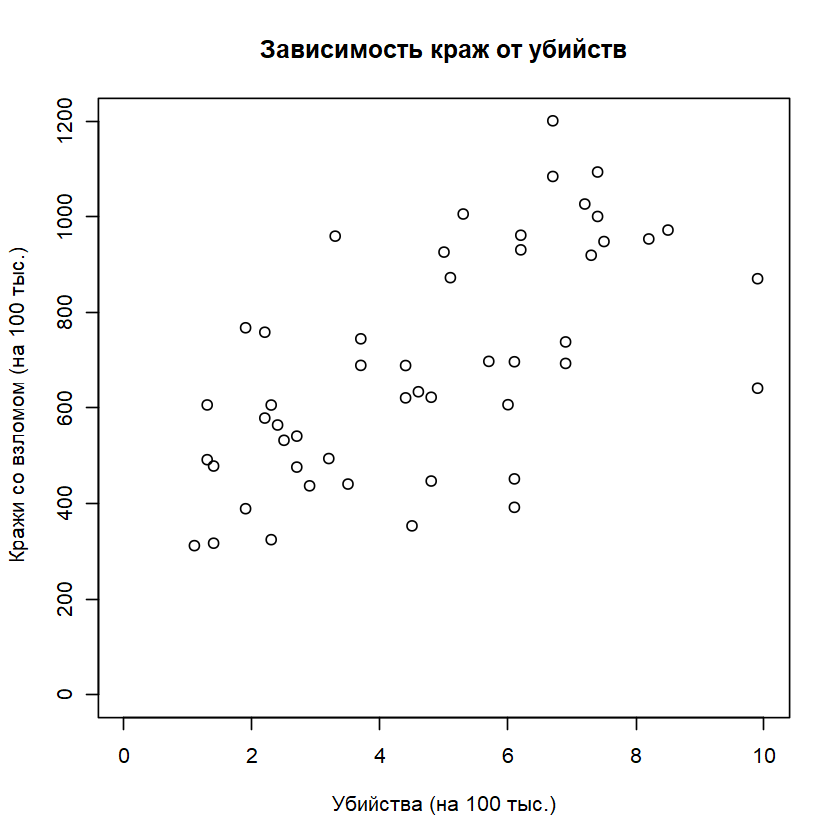

In [48]:
plot(crime2$murder, crime2$burglary, xlim=c(0, 10), ylim=c(0, 1200), xlab="Убийства (на 100 тыс.)", ylab="Кражи со взломом (на 100 тыс.)",  main="Зависимость краж от убийств")

Добавим кривую чтобы сделать более наглядной диаграмму

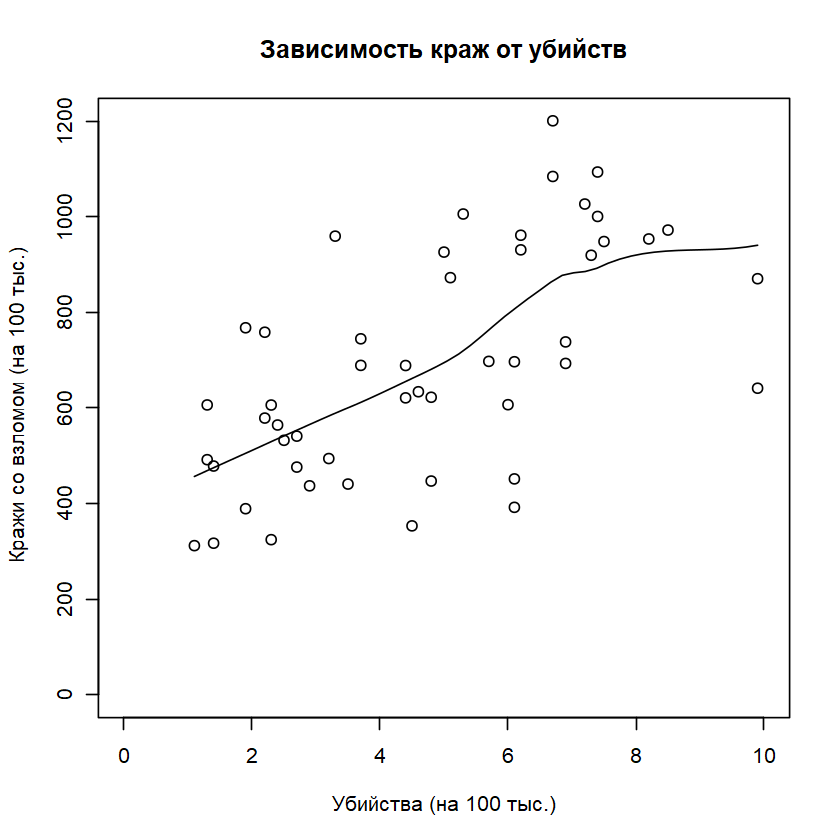

In [49]:
scatter.smooth(crime2$murder, crime2$burglary, xlim=c(0, 10), ylim=c(0, 1200), xlab="Убийства (на 100 тыс.)", ylab="Кражи со взломом (на 100 тыс.)",  main="Зависимость краж от убийств")

<h3>2. Пары в матрицах рассеивания</h3>

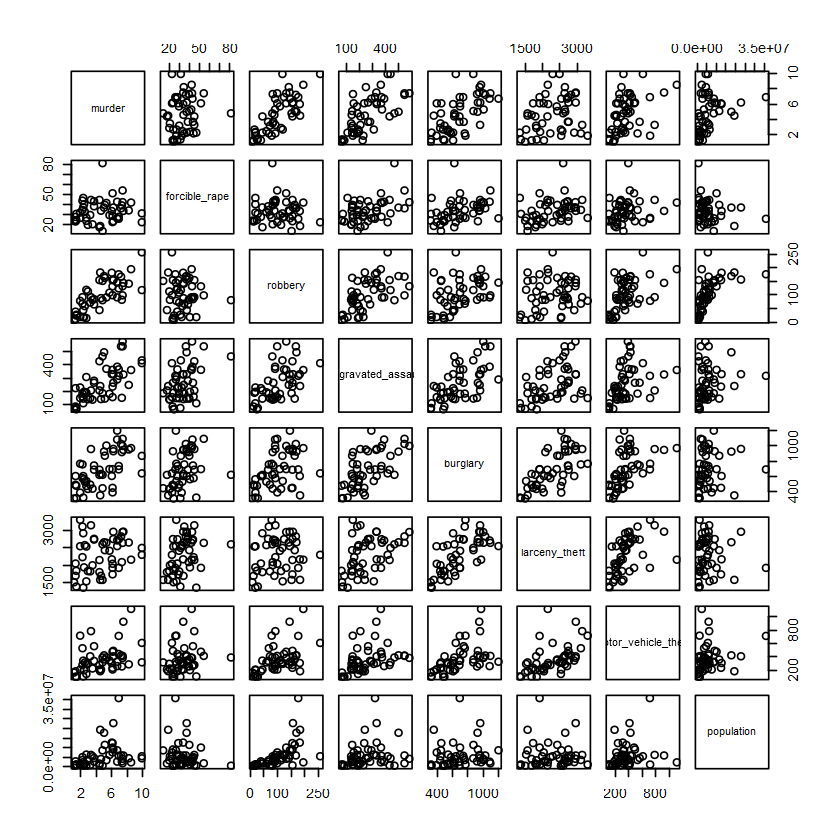

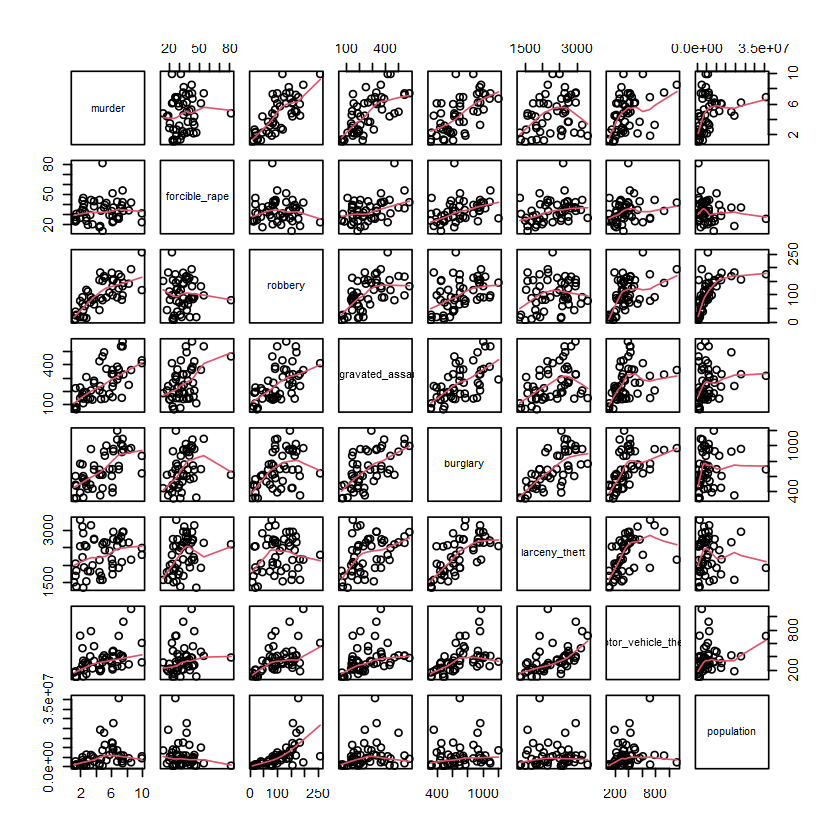

In [50]:
plot (crime2[,2:9])
pairs(crime2[,2:9], panel=panel.smooth)

<h3>3. Пузырьковая диаграмма</h3>

In [51]:
crime <-read.csv("http://datasets.flowingdata.com/crimeRatesByState2005.tsv", header=TRUE, sep="\t")

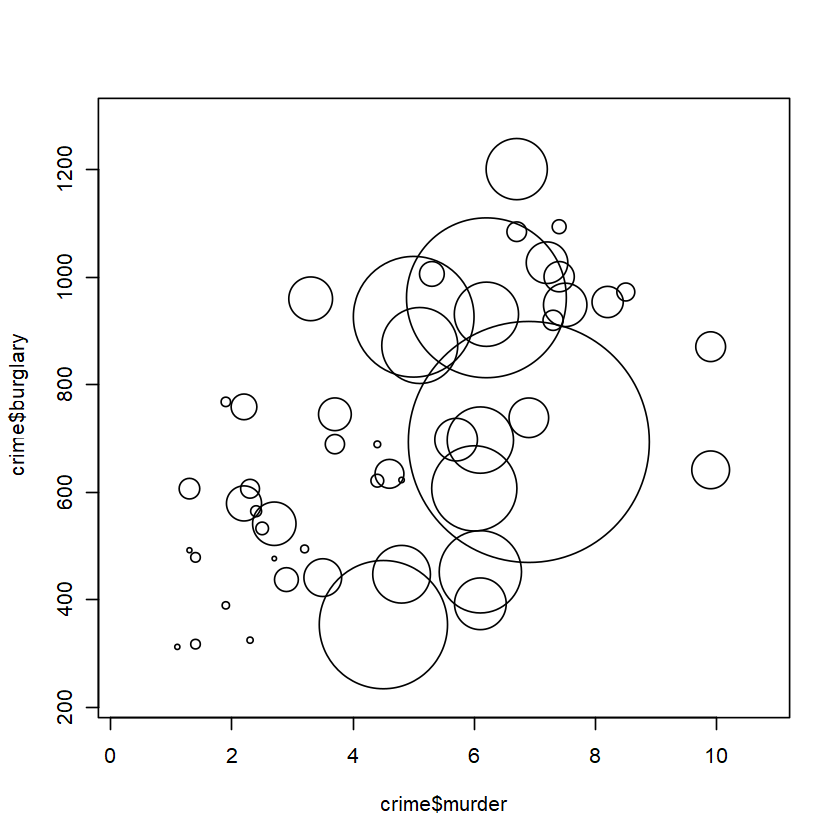

In [52]:
symbols(crime$murder, crime$burglary, circles=crime$population)

Нам необходимо, чтобы площадь, а не радиус, была пропорциональна численности населения. Чтобы определить размер радиусов корректно извлекаем квадратный корень

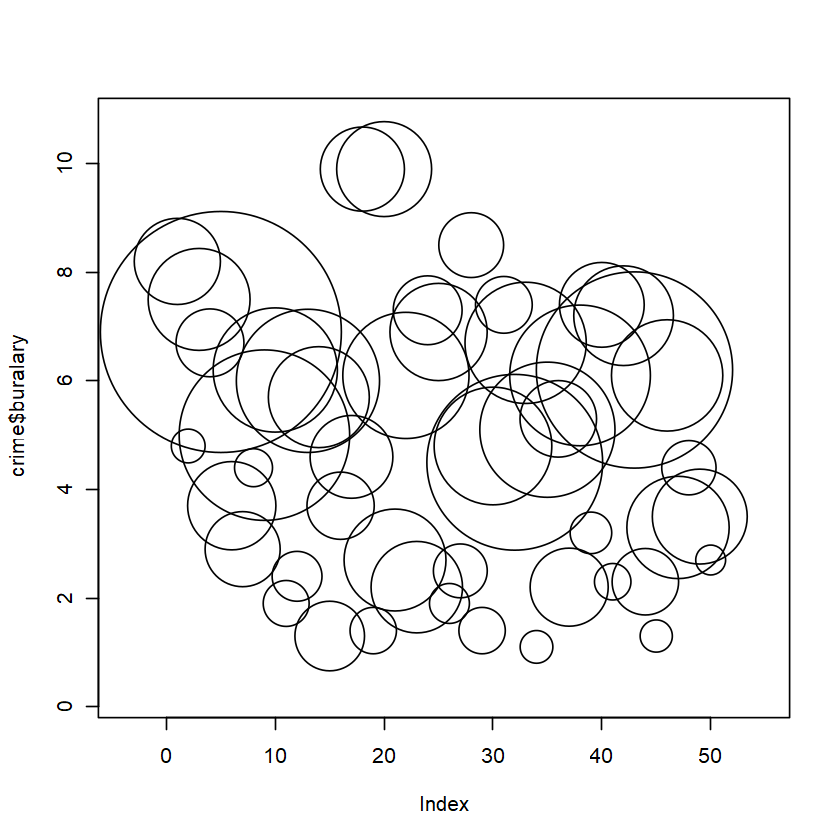

In [53]:
radius <- sqrt(crime$population/ pi )
symbols(crime$murder, crime$buralary, circles=radius)

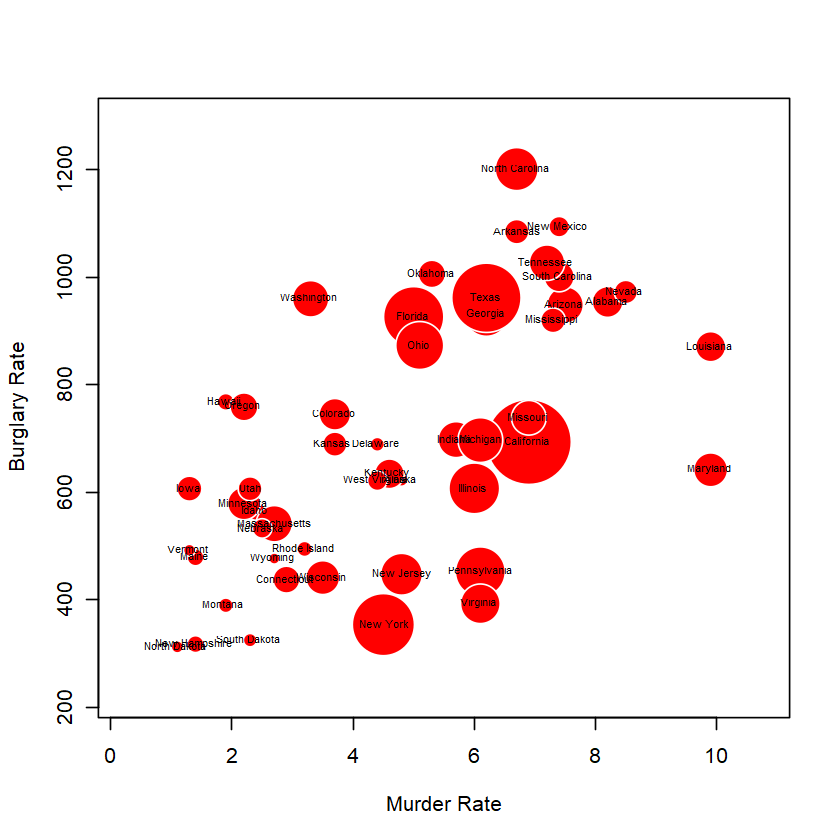

In [55]:
symbols(crime$murder, crime$burglary, circles=radius, inches=0.35, fg="white", bg="red", xlab="Murder Rate", ylab="Burglary Rate")
text(crime$murder, crime$burglary, crime$state, cex=0.5)

**Дополнительно** <br>
Нарисовали вместо кругов диаграмму из квадратов, для точного изображения квадратов извлекли квадратный корень из стороны



In [56]:
length = sqrt(crime$population)

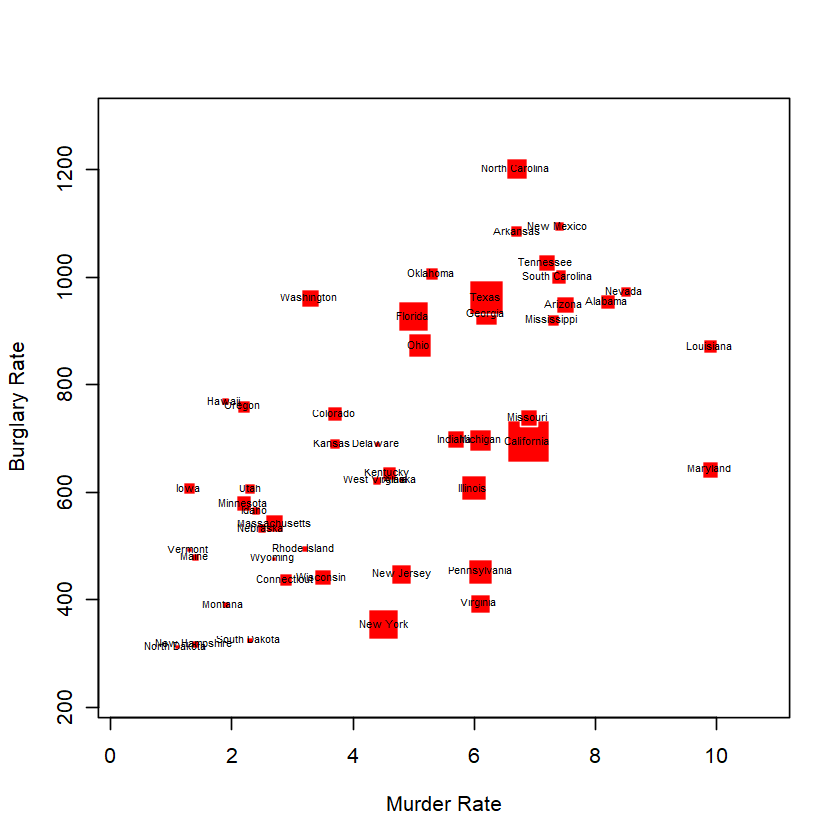

In [57]:
symbols(crime$murder, crime$burglary, squares = length, inches=0.35, fg="white", bg="red", xlab="Murder Rate", ylab="Burglary Rate")
text(crime$murder, crime$burglary, crime$state, cex=0.5)

<h2>Часть 3</h2>
<h3>1. Статистика игр национальной баскетбольной ассоциации</h3>

In [58]:
bball <-read.csv("http://datasets.flowingdata.com/ppg2008.csv", sep=",", header=TRUE)

In [59]:
bball[1:5, ]

,Name,G,MIN,PTS,FGM,FGA,FGP,FTM,FTA,FTP,⋯,X3PA,X3PP,ORB,DRB,TRB,AST,STL,BLK,TO,PF
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Dwyane Wade,79,38.6,30.2,10.8,22.0,0.491,7.5,9.8,0.765,⋯,3.5,0.317,1.1,3.9,5.0,7.5,2.2,1.3,3.4,2.3
2,LeBron James,81,37.7,28.4,9.7,19.9,0.489,7.3,9.4,0.780,⋯,4.7,0.344,1.3,6.3,7.6,7.2,1.7,1.1,3.0,1.7
3,Kobe Bryant,82,36.2,26.8,9.8,20.9,0.467,5.9,6.9,0.856,⋯,4.1,0.351,1.1,4.1,5.2,4.9,1.5,0.5,2.6,2.3
4,Dirk Nowitzki,81,37.7,25.9,9.6,20.0,0.479,6.0,6.7,0.890,⋯,2.1,0.359,1.1,7.3,8.4,2.4,0.8,0.8,1.9,2.2
5,Danny Granger,67,36.2,25.8,8.5,19.1,0.447,6.0,6.9,0.878,⋯,6.7,0.404,0.7,4.4,5.1,2.7,1.0,1.4,2.5,3.1


Сортировка данных по показателям, например по процену попаданий с игры, с помощью order().

In [60]:
bball_byfgp <- bball[order (bball$FGP, decreasing=TRUE),]
bball_byfgp [1:5,]

,Name,G,MIN,PTS,FGM,FGA,FGP,FTM,FTA,FTP,⋯,X3PA,X3PP,ORB,DRB,TRB,AST,STL,BLK,TO,PF
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
46,Shaquille O'neal,75,30.1,17.8,6.8,11.2,0.609,4.1,6.9,0.595,⋯,0.0,0.000,2.5,5.9,8.4,1.7,0.7,1.4,2.2,3.4
25,Dwight Howard,79,35.7,20.6,7.1,12.4,0.572,6.4,10.7,0.594,⋯,0.0,0.000,4.3,9.6,13.8,1.4,1.0,2.9,3.0,3.4
36,Pau Gasol,81,37.1,18.9,7.3,12.9,0.567,4.2,5.4,0.781,⋯,0.0,0.500,3.2,6.4,9.6,3.5,0.6,1.0,1.9,2.1
29,Yao Ming,77,33.6,19.7,7.4,13.4,0.548,4.9,5.7,0.866,⋯,0.0,1.000,2.6,7.2,9.9,1.8,0.4,1.9,3.0,3.3
15,Amare Stoudemire,53,36.8,21.4,7.6,14.1,0.539,6.1,7.3,0.835,⋯,0.1,0.429,2.2,5.9,8.1,2.0,0.9,1.1,2.8,3.1


Сортировка по возрастанию

In [61]:
bball <- bball[order (bball$PTS, decreasing=FALSE),]
bball[1:5,]

,Name,G,MIN,PTS,FGM,FGA,FGP,FTM,FTA,FTP,⋯,X3PA,X3PP,ORB,DRB,TRB,AST,STL,BLK,TO,PF
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
50,Nate Robinson,74,29.9,17.2,6.1,13.9,0.437,3.4,4.0,0.841,⋯,5.2,0.325,1.3,2.6,3.9,4.1,1.3,0.1,1.9,2.8
49,Allen Iverson,57,36.7,17.5,6.1,14.6,0.417,4.8,6.1,0.781,⋯,1.7,0.283,0.5,2.5,3.0,5.0,1.5,0.1,2.6,1.5
47,Rashard Lewis,79,36.2,17.7,6.1,13.8,0.439,2.8,3.4,0.836,⋯,7.0,0.397,1.2,4.6,5.7,2.6,1.0,0.6,2.0,2.5
48,Chauncey Billups,79,35.3,17.7,5.2,12.4,0.418,5.3,5.8,0.913,⋯,5.0,0.408,0.4,2.6,3.0,6.4,1.2,0.2,2.2,2.0
45,Maurice Williams,81,35.0,17.8,6.5,13.9,0.467,2.6,2.8,0.912,⋯,5.2,0.436,0.6,2.9,3.4,4.1,0.9,0.1,2.2,2.7


In [62]:
row.names(bball) <- bball$Name
bball <- bball[,2:20]

In [63]:
bball_matrix <-data.matrix(bball)

Создание тепловой карты

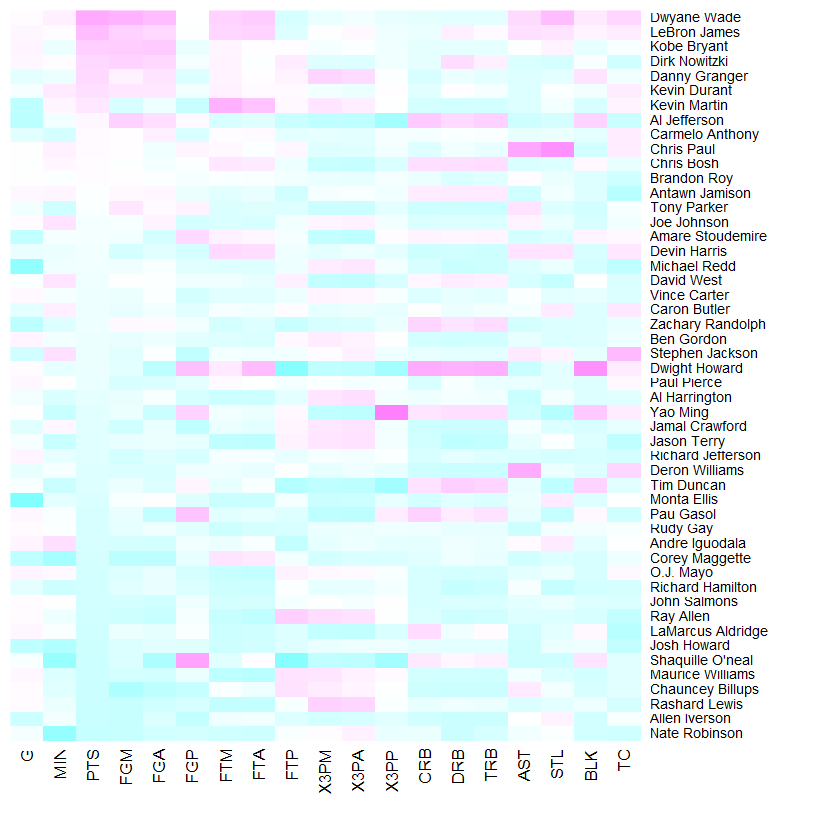

In [64]:
ball_heatmap <- heatmap(bball_matrix, Rowv=NA, Colv=NA, col = cm.colors(256), scale="column", margins=c(5,10))

Задаем цвета через массив

In [65]:
g_colors <- c("#fff1fa", "#ffe9f7", "#ffe0f5", "#ffd8f2", "#ffd0f0", "#ffc8ee", "#ffbfec", "#ffb7e9", "#ffaee7", "#f8a8e0")

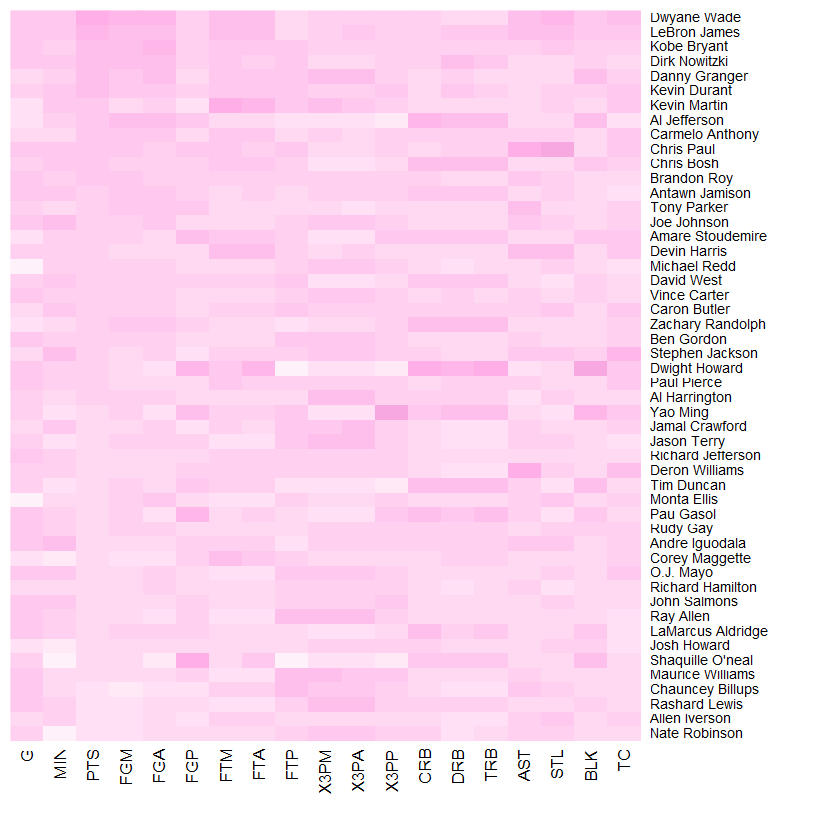

In [66]:
ball_heatmap <- heatmap(bball_matrix, Rowv=NA, Colv=NA, col = g_colors, scale="column", margins=c(5,10))

Задаем цвета с помощью библиотеки RColorBrewer

In [69]:
install.packages("RColorBrewer")

Устанавливаю пакет в 'C:/Users/ol1xy/AppData/Local/R/win-library/4.5'
(потому что 'lib' не определено)



пакет 'RColorBrewer' успешно распакован, MD5-суммы проверены

Скачанные бинарные пакеты находятся в
	C:\Users\ol1xy\AppData\Local\Temp\RtmpCE6CSs\downloaded_packages


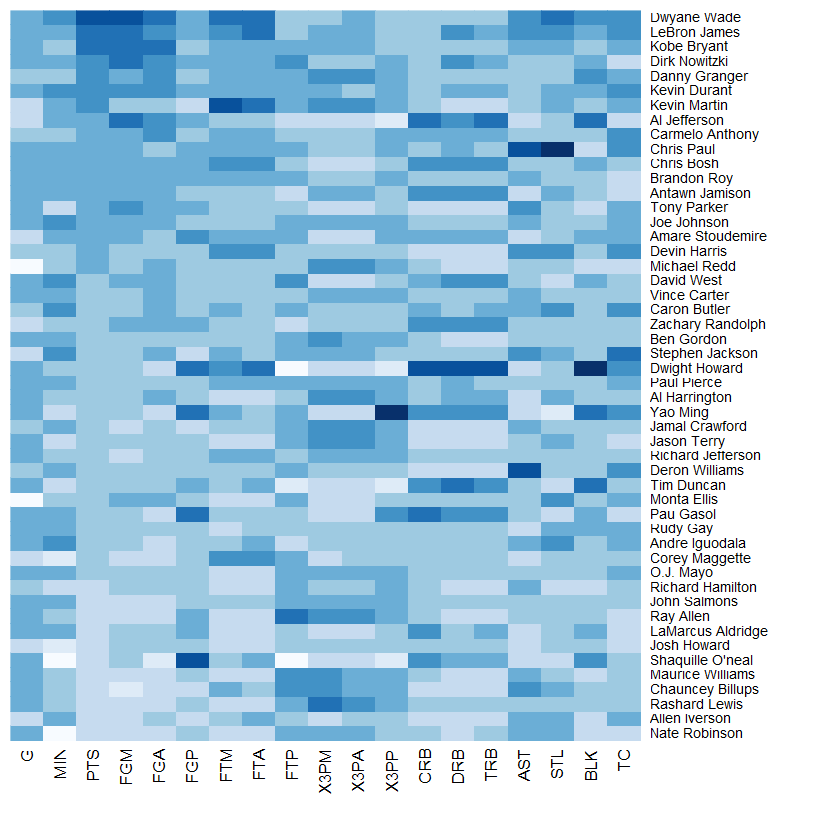

In [70]:
library(RColorBrewer)
bball_heatmap <- heatmap(bball_matrix, Rowv=NA, Colv=NA, col = brewer.pal(9, "Blues"), scale="column", margins=c(5,10))

<h3>2. Лица Чернова</h3>

In [72]:
install.packages("aplpack")
library(aplpack)

Устанавливаю пакет в 'C:/Users/ol1xy/AppData/Local/R/win-library/4.5'
(потому что 'lib' не определено)



пакет 'aplpack' успешно распакован, MD5-суммы проверены

Скачанные бинарные пакеты находятся в
	C:\Users\ol1xy\AppData\Local\Temp\RtmpCE6CSs\downloaded_packages


effect of variables:
 modified item       Var   
 "height of face   " "MIN" 
 "width of face    " "PTS" 
 "structure of face" "FGM" 
 "height of mouth  " "FGA" 
 "width of mouth   " "FGP" 
 "smiling          " "FTM" 
 "height of eyes   " "FTA" 
 "width of eyes    " "FTP" 
 "height of hair   " "X3PM"
 "width of hair   "  "X3PA"
 "style of hair   "  "X3PP"
 "height of nose  "  "ORB" 
 "width of nose   "  "DRB" 
 "width of ear    "  "TRB" 
 "height of ear   "  "AST" 


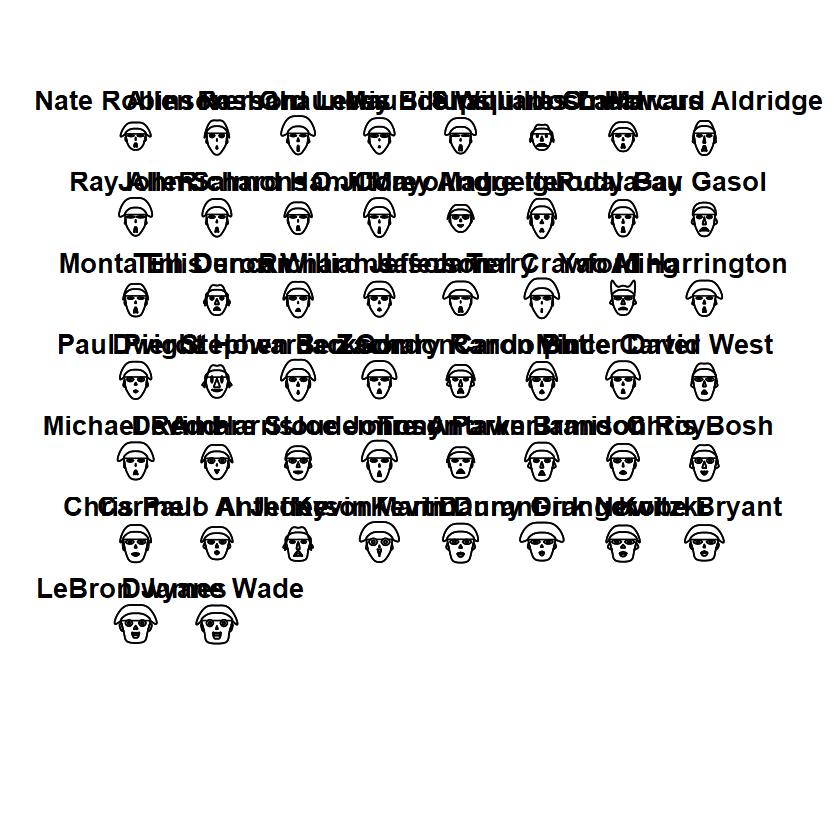

In [73]:
faces(bball[,2:16], ncolors=0)

<h3>2*. Лица Чернова для карты преступности</h3>

effect of variables:
 modified item       Var                
 "height of face   " "murder"           
 "width of face    " "Forcible_rate"    
 "structure of face" "Robbery"          
 "height of mouth  " "aggravated_assult"
 "width of mouth   " "burglary"         
 "smiling          " "larceny_theft"    
 "height of eyes   " "murder"           
 "width of eyes    " "Forcible_rate"    
 "height of hair   " "Robbery"          
 "width of hair   "  "aggravated_assult"
 "style of hair   "  "burglary"         
 "height of nose  "  "larceny_theft"    
 "width of nose   "  "murder"           
 "width of ear    "  "Forcible_rate"    
 "height of ear   "  "Robbery"          


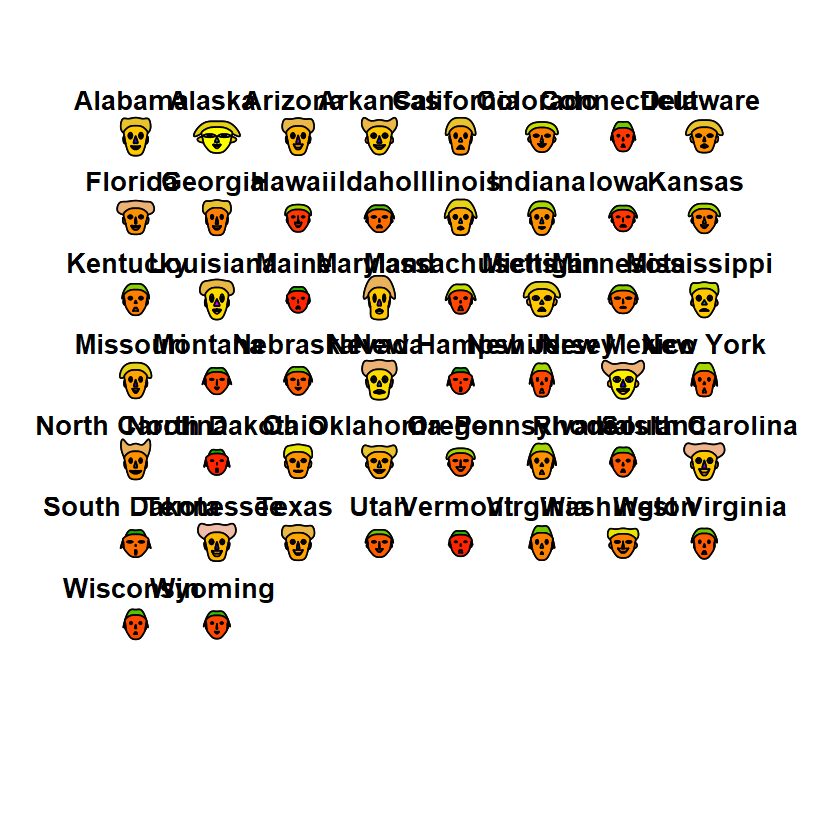

In [74]:
faces(crime[, 2:7], labels = crime$state)

<h3>3. Диаграммы-радары</h3>

In [75]:
crime <-read.csv("http://datasets.flowingdata.com/crimeRatesByState2005.tsv", header=TRUE, sep="\t")

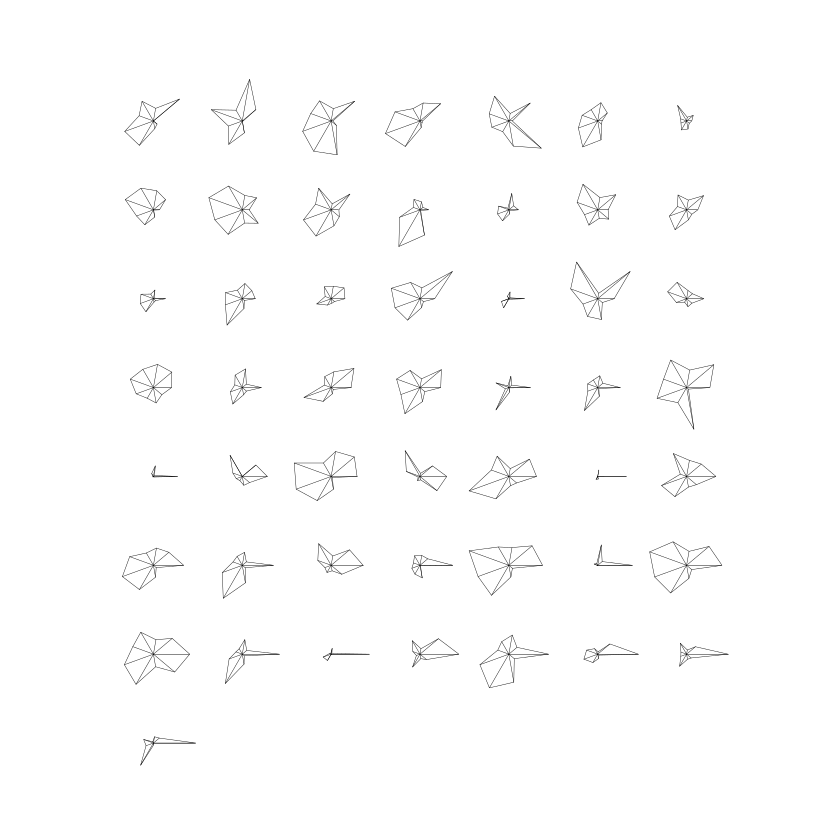

In [76]:
stars(crime)

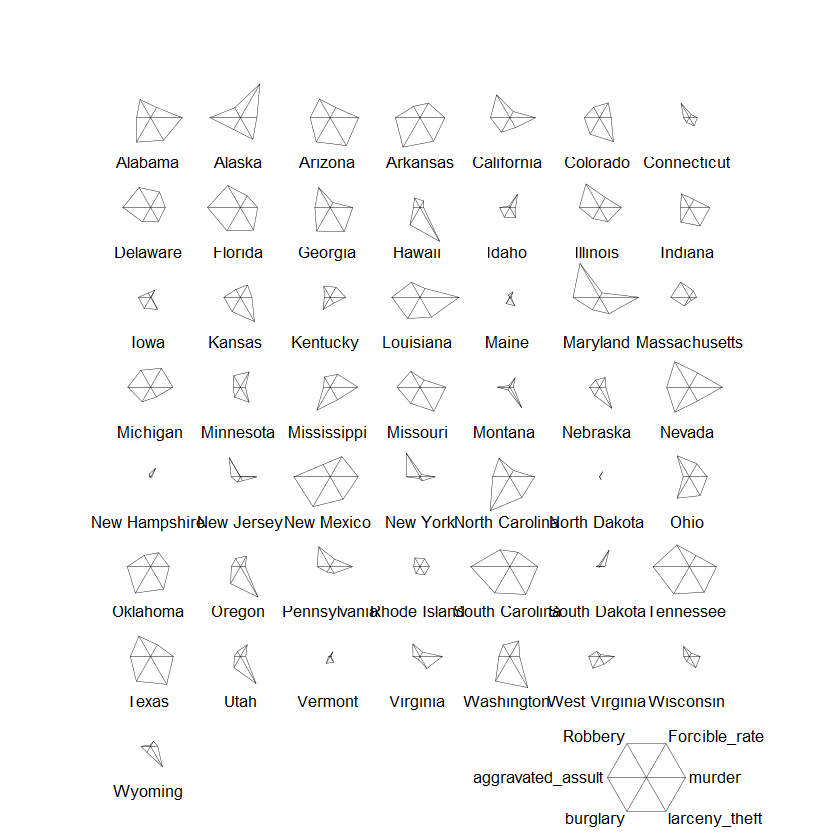

In [77]:
row.names(crime) <- crime$state
crime <- crime[,2:7]
stars(crime, flip.labels=FALSE, key.loc = c(15, 1.5))

Ограничим пространство
размещения данных только верхней половиной круга:

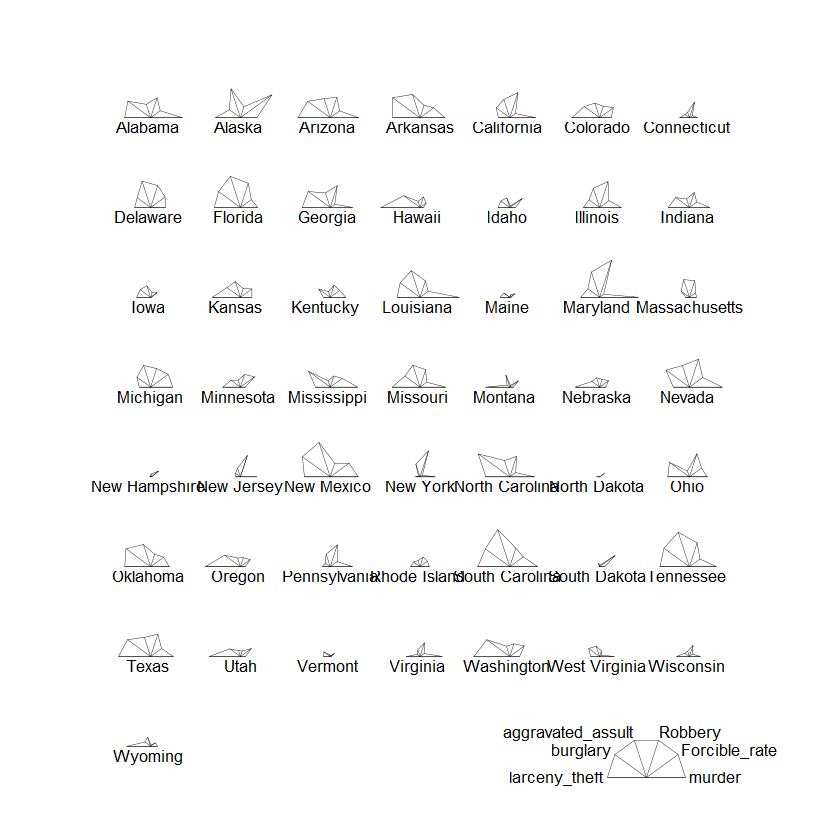

In [78]:
stars(crime, flip.labels=FALSE, key.loc = c(15, 1.5), full=FALSE)

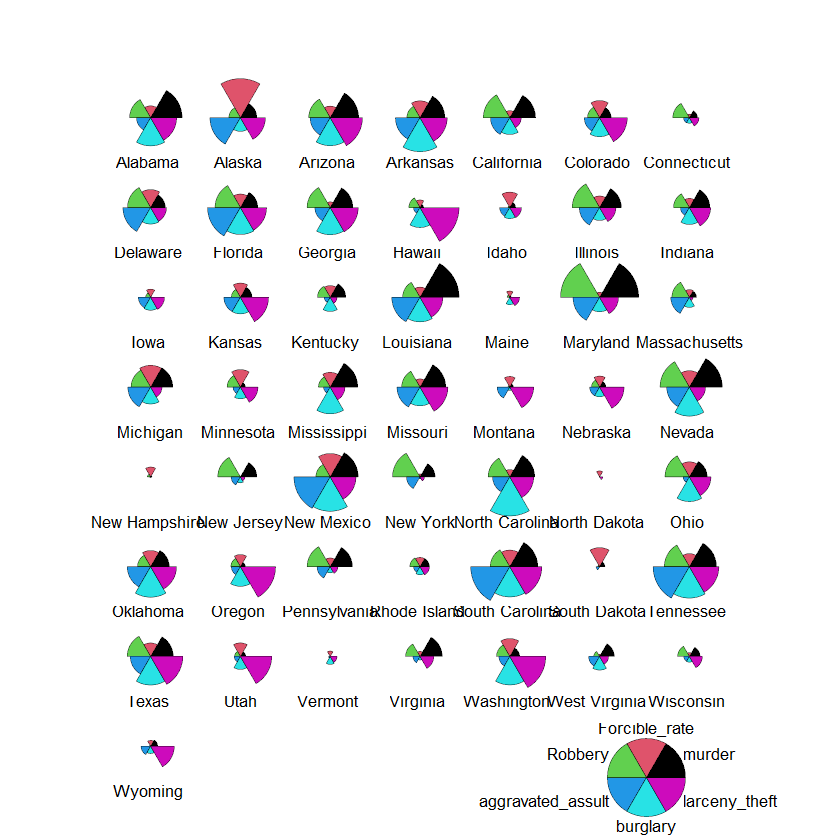

In [79]:
stars(crime, flip.labels=FALSE, key.loc = c(15, 1.5), draw.segments=TRUE)